In [1]:
import os
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler
import joblib
import seaborn as sns
sns.set(color_codes=True)
import matplotlib.pyplot as plt
%matplotlib inline

from numpy.random import seed
import tensorflow as tf
seed(10)
tf.random.set_seed(10)
tf.get_logger().setLevel('ERROR')


In [3]:
from google.colab import files
import io

uploaded = files.upload()

for filename, file_content in uploaded.items():
    file_bytes = io.StringIO(file_content.decode('utf-8'))
    dataset = pd.read_csv(file_bytes, sep=r',', header=None)
    merged_data = dataset.iloc[1:, :].values.astype(float)

Saving sensor_data (3).csv to sensor_data (3).csv


In [4]:

train = pd.DataFrame(merged_data[:149, :2], columns=['Temperature', 'Humidity'])
test_full = pd.DataFrame(merged_data[162:, :], columns=['Temperature', 'Humidity', 'Occupancy'])
test = test_full[['Temperature', 'Humidity']].copy()
y_test = test_full['Occupancy'].astype(int).values
val_full = pd.DataFrame(merged_data[149:162,:],columns=['Temperature', 'Humidity', 'Occupancy'])
val = val_full[['Temperature', 'Humidity']].copy()
y_val = val_full['Occupancy'].astype(int).values
print(train.head())


   Temperature  Humidity
0         31.8      53.0
1         31.7      52.9
2         31.7      52.9
3         31.8      52.9
4         31.8      52.9


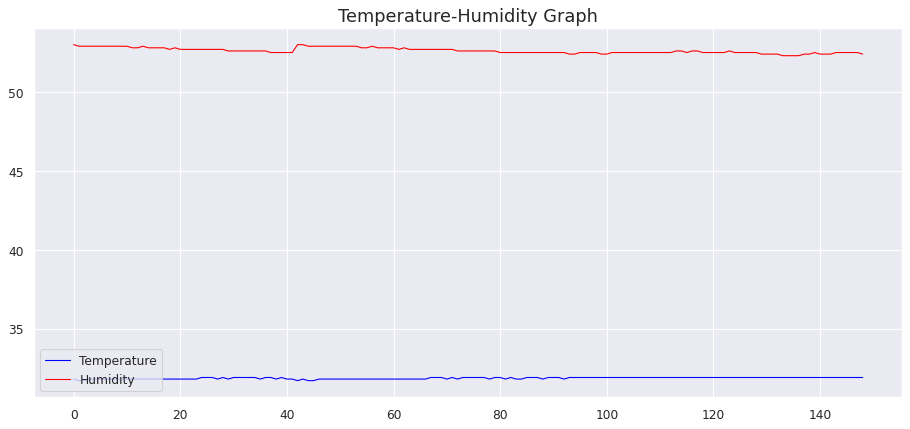

In [5]:
fig, ax = plt.subplots(figsize=(14, 6), dpi=80)
ax.plot(train['Temperature'], label='Temperature', color='blue', animated = True, linewidth=1)
ax.plot(train['Humidity'], label='Humidity', color='red', animated = True, linewidth=1)
plt.legend(loc='lower left')
ax.set_title('Temperature-Humidity Graph', fontsize=16)
plt.show()

In [8]:
scaler = MinMaxScaler()
WINDOW = 5
def create_sequences(data, window):
    X = []
    for i in range(len(data) - window):
        X.append(data[i : i + window])
    return np.array(X)

X_train = create_sequences(scaler.fit_transform(train.values), WINDOW)
X_test = create_sequences(scaler.transform(test.values), WINDOW)
X_val = create_sequences(scaler.transform(val.values), WINDOW)


In [9]:
from tensorflow.keras.layers import (
    Input, LSTM, Dense, RepeatVector,
    TimeDistributed, LayerNormalization
)
from tensorflow.keras.models import Model
def autoencoder_model(X):
    inputs = Input(shape=(X.shape[1], X.shape[2]))
    L1 = LSTM(32, return_sequences=True)(inputs)
    L1 = LayerNormalization()(L1)
    L2 = LSTM(16, return_sequences=True)(L1)
    L2 = LayerNormalization()(L2)
    L3 = LSTM(4, return_sequences=False)(L2)
    L4 = RepeatVector(X.shape[1])(L3)
    L5 = LSTM(16, return_sequences=True)(L4)
    L5 = LayerNormalization()(L5)
    L6 = LSTM(32, return_sequences=True)(L5)
    output = TimeDistributed(Dense(X.shape[2]))(L6)

    model = Model(inputs=inputs, outputs=output)
    return model

In [10]:
model = autoencoder_model(X_train)
model.compile(optimizer='adam', loss='mae')
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 5, 2)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 5, 32)          │         4,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ layer_normalization             │ (None, 5, 32)          │            64 │
│ (LayerNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 5, 16)          │         3,136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ layer_normalization_1           │ (None, 5, 16)          │            32 │
│ (LayerNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ (None, 4)              │           336 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ repeat_vector (RepeatVector)    │ (None, 5, 4)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_3 (LSTM)                   │ (None, 5, 16)          │         1,344 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ layer_normalization_2           │ (None, 5, 16)          │            32 │
│ (LayerNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_4 (LSTM)                   │ (None, 5, 32)          │         6,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed                │ (None, 5, 2)           │            66 │
│ (TimeDistributed)               │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 15,762 (61.57 KB)

 Trainable params: 15,762 (61.57 KB)

 Non-trainable params: 0 (0.00 B)

In [11]:
nb_epochs = 50
batch_size = 10
history = model.fit(X_train, X_train, epochs=nb_epochs, batch_size=batch_size,
                    validation_split=0.05).history

Epoch 1/50
14/14 ━━━━━━━━━━━━━━━━━━━━ 12s 107ms/step - loss: 0.5461 - val_loss: 0.3062
Epoch 2/50
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 0.2383 - val_loss: 0.1518
Epoch 3/50
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 0.1849 - val_loss: 0.1445
Epoch 4/50
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 0.1578 - val_loss: 0.1111
Epoch 5/50
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.1384 - val_loss: 0.0932
Epoch 6/50
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 0.1215 - val_loss: 0.0836
Epoch 7/50
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.1139 - val_loss: 0.0778
Epoch 8/50
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 0.1078 - val_loss: 0.0731
Epoch 9/50
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 0.1051 - val_loss: 0.0725
Epoch 10/50
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.1017 - val_loss: 0.0673
Epoch 11/50
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.0997 - val_loss: 0.0633
Epoch 12/50
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 0

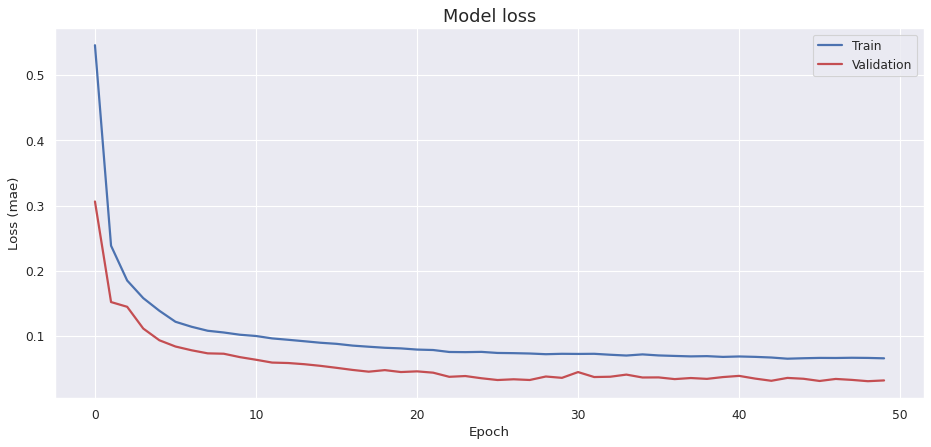

In [12]:
fig, ax = plt.subplots(figsize=(14, 6), dpi=80)
ax.plot(history['loss'], 'b', label='Train', linewidth=2)
ax.plot(history['val_loss'], 'r', label='Validation', linewidth=2)
ax.set_title('Model loss', fontsize=16)
ax.set_ylabel('Loss (mae)')
ax.set_xlabel('Epoch')
ax.legend(loc='upper right')
plt.show()

In [13]:
X_pred = model.predict(X_test)
error_vectors = np.abs(X_pred - X_test)
error_vectors = error_vectors.reshape(error_vectors.shape[0], -1)
X_pred_train = model.predict(X_train)
error_train = np.abs(X_pred_train - X_train)
error_train = error_train.reshape(error_train.shape[0], -1)
mu = np.mean(error_train, axis=0)
sigma = np.cov(error_train, rowvar=False)
sigma += 1e-6 * np.eye(sigma.shape[0])

2/2 ━━━━━━━━━━━━━━━━━━━━ 2s 1s/step
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step


In [14]:
inv_sigma = np.linalg.inv(sigma)
scores = []
for e in error_vectors:
    diff = e - mu
    score = diff.T @ inv_sigma @ diff
    scores.append(score)

scores = np.array(scores)

In [15]:
X_val_pred = model.predict(X_val)
error_val = np.abs(X_val_pred - X_val)
error_val = error_val.reshape(error_val.shape[0], -1)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step


In [16]:
val_scores = []
for e in error_val:
    diff = e - mu
    score = diff.T @ inv_sigma @ diff
    val_scores.append(score)

val_scores = np.array(val_scores)

In [17]:
window_size = WINDOW
y_val_window = []

for i in range(len(y_val) - window_size ):
    window = y_val[i:i+window_size]
    label = 1 if np.any(window == 1) else 0
    y_val_window.append(label)

y_val_window = np.array(y_val_window)

In [18]:
print(val_scores.shape)
print(y_val_window.shape)
print(error_val.shape)

(8,)
(8,)
(8, 10)


In [19]:
from sklearn.metrics import f1_score
best_f1 = 0
best_threshold = 0
for t in np.linspace(min(val_scores), max(val_scores), 100):
    y_pred = (val_scores > t).astype(int)
    f1 = f1_score(y_val_window, y_pred)

    if f1 > best_f1:
        best_f1 = f1
        best_threshold = t

In [20]:
threshold = best_threshold

In [21]:
window_size = WINDOW
y_test_window = []

for i in range(len(y_test) - window_size ):
    window = y_test[i:i+window_size]
    label = 1 if np.any(window == 1) else 0
    y_test_window.append(label)

y_test_window = np.array(y_test_window)

In [22]:
scored = pd.DataFrame()
scored['AnomalyScore'] = scores
scored['Threshold'] = threshold
scored['Anomaly'] = scored['AnomalyScore'] > threshold
y_test_aligned = y_test_window
scored['Actual Anomaly'] = y_test_aligned.astype(bool)
from sklearn.metrics import (
    accuracy_score
)
y_pred = scored['Anomaly'].astype(int).values
y_true = y_test_aligned
acc = accuracy_score(y_true, y_pred)
print(f"\n Accuracy  : {acc * 100:.2f}%")
print(scored)



 Accuracy  : 97.62%
     AnomalyScore     Threshold  Anomaly  Actual Anomaly
0    14318.693137  21430.435293    False            True
1    23644.733549  21430.435293     True            True
2    35413.550920  21430.435293     True            True
3    49064.350503  21430.435293     True            True
4    65350.157242  21430.435293     True            True
5    81052.789829  21430.435293     True            True
6    95978.746135  21430.435293     True            True
7   110649.025293  21430.435293     True            True
8   120640.116693  21430.435293     True            True
9   129023.394529  21430.435293     True            True
10  129379.762268  21430.435293     True            True
11  105116.479090  21430.435293     True            True
12   73373.973055  21430.435293     True            True
13   47950.463032  21430.435293     True            True
14   31428.064624  21430.435293     True            True
15   20182.973344  21430.435293    False           False
16   13015

<Axes: >

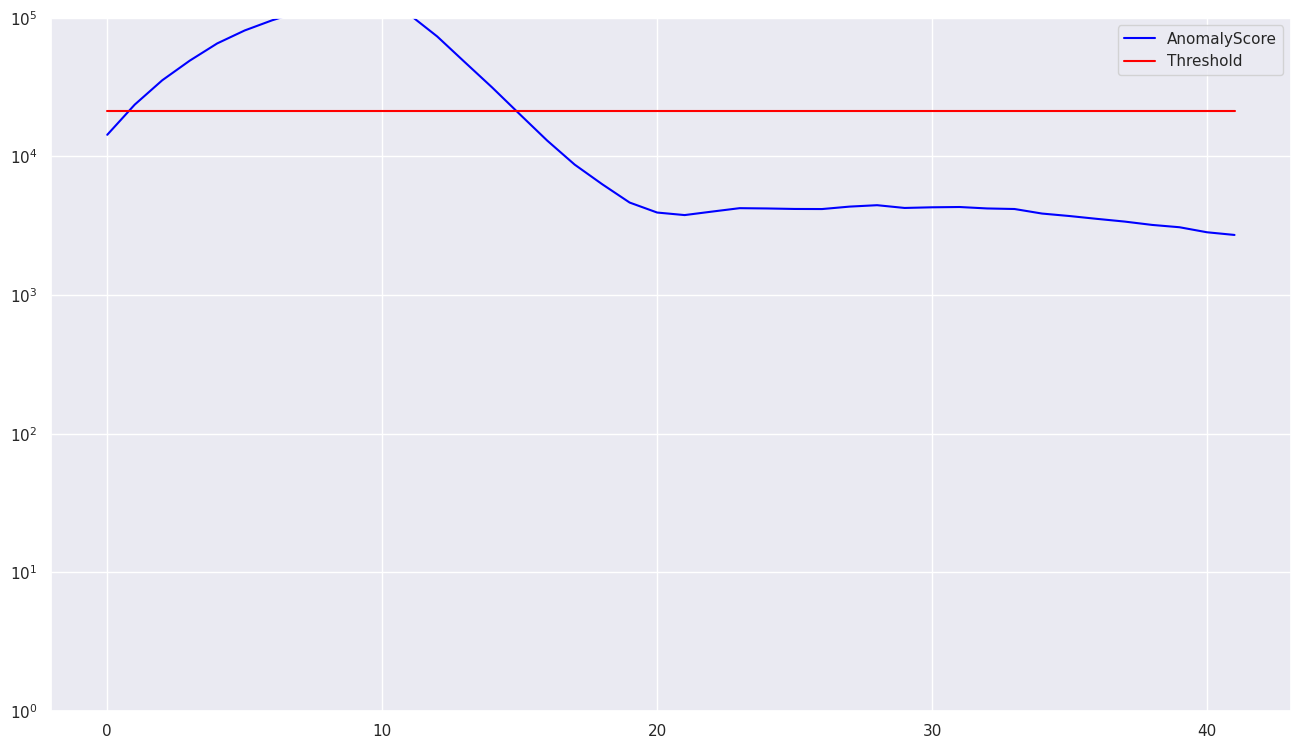

In [23]:

scored.plot(logy=True,  figsize=(16,9), ylim=[1e0,1e5], color=['blue','red'])


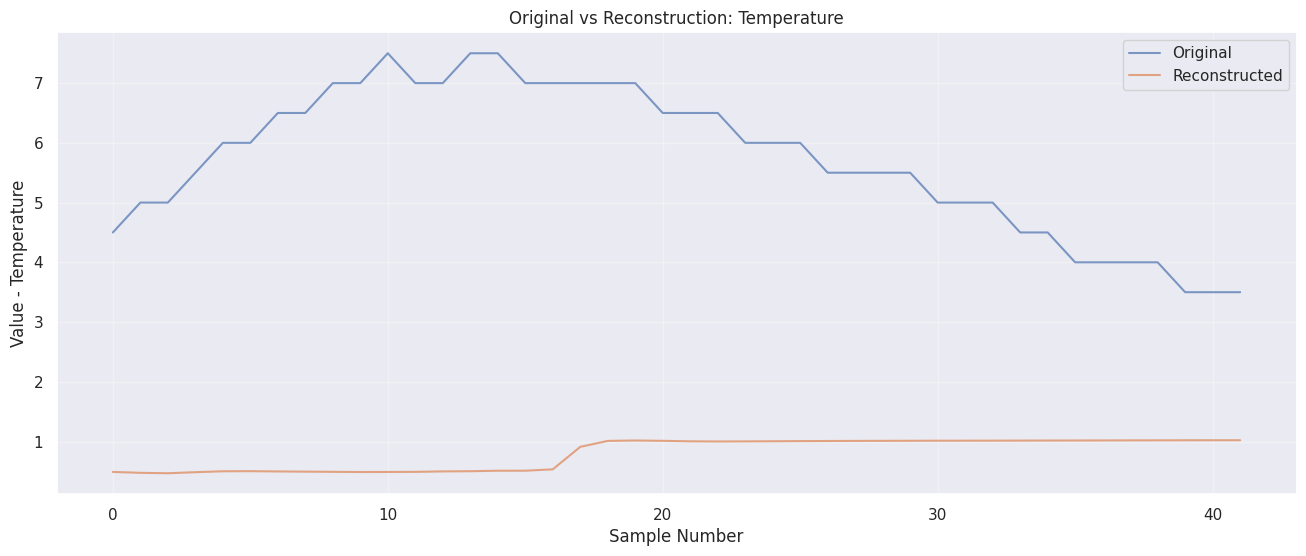

In [24]:
import matplotlib.pyplot as plt
feature_index = 0
feature_name = test.columns[feature_index]
original = X_test[:, -1, feature_index]
reconstructed = X_pred[:, -1, feature_index]
plt.figure(figsize=(16, 6))
plt.plot(original, label='Original', alpha=0.7)
plt.plot(reconstructed, label='Reconstructed', alpha=0.7)
plt.xlabel('Sample Number')
plt.ylabel(f'Value - {feature_name}')
plt.title(f'Original vs Reconstruction: {feature_name}')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [25]:
model.save("Cloud_model.h5")